<a href="https://colab.research.google.com/github/Maryam-Skaik/fire-alarm-detection-perfect-separation/blob/main/notebook/fire_detection_using_smoke_detector_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fire Detection using Smoke Detector Data

### Goal

Predict whether a **fire is detected** based on sensor readings.

### Problem Type Identification
- Target variable: `Fire Alarm` (binary: 0 or 1)
- Therefore: **Classification Problem**

## Imports

In [61]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

## Custom Functions

In [62]:
def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)

  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)

  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)

  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None, cmap='gist_gray', colorbar=colorbar, ax = axes[0],);
  axes[0].set_title("Raw Counts")

  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize, cmap=cmap, colorbar=colorbar, ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()

  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [63]:
def evaluate_classification(model, X_train, y_train, X_test, y_test, figsize=(6,4), normalize='true', output_dict = False, cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, output_dict=True, figsize=figsize, colorbar=colorbar, cmap=cmap_train, label='Training Data')
  print()

  # Get predictions for test data
  y_test_pred = model.predict(X_test)

  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, output_dict=True,figsize=figsize, colorbar=colorbar, cmap=cmap_test, label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train, 'test': results_test}
    return results_dict

## Load Dataset

In [26]:
fpath = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTAQMDlyQdVuWy9le6OcM14fIZdQKg0s_PXhWUYIjUoB_rFpOz9Sv0K05ryiIQkTezghYtkLj6maFCW/pub?gid=2097390352&single=true&output=csv"
df = pd.read_csv(fpath)
df.head()

,Unnamed: 0,Unnamed: 1,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,0,1655127852,19.117,56.52,400,13314.0,High,med,1.71,1.78,11.77,1.835,0.041,1928,0
1,1,1,1654777894,NaN,55.78,400,12889.0,Low,High,1.71,1.78,11.79,1.838,0.042,22541,1
2,2,2,1654785729,26.160,51.93,406,12989.0,Low,High,1.95,2.03,13.43,2.095,0.047,20717,1
3,3,3,1654773681,26.960,52.51,577,NaN,Low,High,2.31,2.40,15.91,2.481,0.056,22852,1
4,4,4,1654779348,19.860,NaN,400,12910.0,Low,High,1.72,1.79,11.85,1.848,0.042,14193,1


From first look, we can find 2 uneeded columns: Unnamed: 0, Unnamed: 1.

`Temperature[C]`, `Humidity[%]`, `Raw H2` contain missing values.

Dataset contains numeric, categorical, and ordinal features.

Target feature is: Fire Alarm (categorical)

In [27]:
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 1'])
df.head()

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,1655127852,19.117,56.52,400,13314.0,High,med,1.71,1.78,11.77,1.835,0.041,1928,0
1,1654777894,NaN,55.78,400,12889.0,Low,High,1.71,1.78,11.79,1.838,0.042,22541,1
2,1654785729,26.160,51.93,406,12989.0,Low,High,1.95,2.03,13.43,2.095,0.047,20717,1
3,1654773681,26.960,52.51,577,NaN,Low,High,2.31,2.40,15.91,2.481,0.056,22852,1
4,1654779348,19.860,NaN,400,12910.0,Low,High,1.72,1.79,11.85,1.848,0.042,14193,1


## Data Overview

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62633 entries, 0 to 62632
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             62633 non-null  int64  
 1   Temperature[C]  43843 non-null  float64
 2   Humidity[%]     51985 non-null  float64
 3   eCO2[ppm]       62633 non-null  int64  
 4   Raw H2          47602 non-null  float64
 5   Raw Ethanol     62633 non-null  object 
 6   Pressure[hPa]   62633 non-null  object 
 7   PM1.0           62633 non-null  float64
 8   PM2.5           62633 non-null  float64
 9   NC0.5           62633 non-null  float64
 10  NC1.0           62633 non-null  float64
 11  NC2.5           62633 non-null  float64
 12  CNT             62633 non-null  int64  
 13  Fire Alarm      62633 non-null  int64  
dtypes: float64(8), int64(4), object(2)
memory usage: 6.7+ MB


Dataset contains 62633 rows and 14 columns.

All data types are consistent with features.

As noted before, missing values occur in `Temperature[C]`, `Humidity[%]`, `Raw H2`, all of them are numeric, so just need to impute numeric columns.

In [29]:
df.describe().round(2)

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,6.263300e+04,43843.00,51985.00,62633.00,47602.00,62633.00,62633.00,62633.00,62633.00,62633.00,62633.00,62633.00
mean,1.654792e+09,15.95,48.46,670.01,12943.81,100.59,184.46,491.44,203.58,80.05,10510.88,0.71
std,1.100006e+05,14.36,9.37,1905.84,270.42,922.50,1976.26,4265.56,2214.69,1083.36,7598.04,0.45
min,1.654712e+09,-22.01,-60.98,400.00,10668.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.654743e+09,10.93,47.53,400.00,12831.00,1.28,1.34,8.82,1.38,0.03,3625.00,0.00
50%,1.654762e+09,20.12,50.16,400.00,12924.00,1.81,1.88,12.45,1.94,0.04,9335.00,1.00
75%,1.654778e+09,25.42,53.24,438.00,13109.00,2.09,2.18,14.42,2.25,0.05,17164.00,1.00
max,1.655130e+09,59.93,75.20,60000.00,13803.00,14333.69,45432.26,61482.03,51914.68,30026.44,24993.00,1.00


### 🔹 UTC (Timestamp)
- Large values (~1.65e9)  
- No missing values  

- Max close to 75% → No real outlier meaning (time progression)

---

### 🔹 Temperature [C]
- Range: -22 → 59.93  
- Mean = 15.95, Median ≈ 20.12  
- Missing values + wide range
- Max (59.93) vs 75% (25.42) → Possible high-end outliers  

---

### 🔹 Humidity [%]
- Count = 51985 → ~17% missing  
- Min = -60.98 (invalid)  
- Max = 75.2
- Invalid negative values  
- Max (75.2) vs 75% (53.24) → Slightly high but reasonable  
- Bigger issue = invalid minimum  

---

### 🔹 eCO2 [ppm]
- No missing values  
- Mean = 670, Median = 400  
- Max = 60,000  
- Max (60000) vs 75% (438) → Extreme outliers  

---

### 🔹 Raw H2
- Range: 10668 → 13803  
- Moderate missing values  
- Max (13803) vs 75% (13109) → Slight difference, no strong outliers  

---

### 🔹 PM1.0
- Mean = 100.59, Median ≈ 1.81  
- Max = 14333.69  
- Max (14333) vs 75% (2.09) → Extreme outliers  

---

### 🔹 PM2.5
- Mean = 184.46, Median ≈ 1.88  
- Max = 45432.26
- Max (45432) vs 75% (2.18) → Extreme outliers  

---

### 🔹 NC0.5
- Max = 61482.03
- Max (61482) vs 75% (14.42) → Extreme outliers  

---

### 🔹 NC1.0
- Max (51914.68) vs 75% (2.25) → Extreme outliers  

---

### 🔹 NC2.5
- Max (30026.44) vs 75% (0.051) → Extreme outliers  

---

### 🔹 CNT
- Likely counter feature  
- Max (24993) vs 75% (17164) → Normal progression, no real outliers  

---

### 🔹 Fire Alarm (Target)
- Values: 0 or 1  
- Mean = 0.715  

**Observation:**
- Imbalanced dataset

In [30]:
df.duplicated().sum()

np.int64(0)

## Missing Values Check

In [31]:
df.isna().sum()

,0
UTC,0
Temperature[C],18790
Humidity[%],10648
eCO2[ppm],0
Raw H2,15031
Raw Ethanol,0
Pressure[hPa],0
PM1.0,0
PM2.5,0
NC0.5,0


In [32]:
(df.isna().mean() * 100).round(2)

,0
UTC,0.0
Temperature[C],30.0
Humidity[%],17.0
eCO2[ppm],0.0
Raw H2,24.0
Raw Ethanol,0.0
Pressure[hPa],0.0
PM1.0,0.0
PM2.5,0.0
NC0.5,0.0


Missing values are handled using **SimpleImputer** inside a pipeline to prevent data leakage.

- Numerical features → imputed using median (robust to sensor outliers)
- Categorical features → imputed using most frequent value

This ensures:

- No data leakage (fit only on training data)
- Stable handling of noisy sensor readings

## Data Type Validation

In [33]:
df.dtypes

,0
UTC,int64
Temperature[C],float64
Humidity[%],float64
eCO2[ppm],int64
Raw H2,float64
Raw Ethanol,object
Pressure[hPa],object
PM1.0,float64
PM2.5,float64
NC0.5,float64


- The dataset data types are generally consistent with the underlying data.
- No type conversion is required for these columns at this stage.
- However, categorical columns will need to be encoded (e.g., ordinal or one-hot encoding) before training machine learning models.

## Inconsistent Categorical Values

In [34]:
for col in df.select_dtypes("object").columns:
    print(col, df[col].value_counts())

Raw Ethanol Raw Ethanol
Low         27581
Medium      13276
low          7441
High         6986
medium       3622
high         1893
Very Low     1427
very low      407
Name: count, dtype: int64
Pressure[hPa] Pressure[hPa]
High    39303
high    10688
Med      9026
med      2462
Low       899
low       255
Name: count, dtype: int64


In [35]:
df['Raw Ethanol'] = df['Raw Ethanol'].replace('low', 'Low')
df['Raw Ethanol'] = df['Raw Ethanol'].replace('medium', 'Medium')
df['Raw Ethanol'] = df['Raw Ethanol'].replace('high', 'High')
df['Raw Ethanol'] = df['Raw Ethanol'].replace('very low', 'Very Low')

df['Raw Ethanol'].value_counts()

,count
Raw Ethanol,
Low,35022
Medium,16898
High,8879
Very Low,1834


In [36]:
df['Pressure[hPa]'] = df['Pressure[hPa]'].replace('low', 'Low')
df['Pressure[hPa]'] = df['Pressure[hPa]'].replace('med', 'Med')
df['Pressure[hPa]'] = df['Pressure[hPa]'].replace('high', 'High')

df['Pressure[hPa]'].value_counts()

,count
Pressure[hPa],
High,49991
Med,11488
Low,1154


In [37]:
for col in df.select_dtypes("object").columns:
    print(col, df[col].value_counts())

Raw Ethanol Raw Ethanol
Low         35022
Medium      16898
High         8879
Very Low     1834
Name: count, dtype: int64
Pressure[hPa] Pressure[hPa]
High    49991
Med     11488
Low      1154
Name: count, dtype: int64


## Impossible Numeric Values

In [38]:
df.describe().round(2)

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,6.263300e+04,43843.00,51985.00,62633.00,47602.00,62633.00,62633.00,62633.00,62633.00,62633.00,62633.00,62633.00
mean,1.654792e+09,15.95,48.46,670.01,12943.81,100.59,184.46,491.44,203.58,80.05,10510.88,0.71
std,1.100006e+05,14.36,9.37,1905.84,270.42,922.50,1976.26,4265.56,2214.69,1083.36,7598.04,0.45
min,1.654712e+09,-22.01,-60.98,400.00,10668.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.654743e+09,10.93,47.53,400.00,12831.00,1.28,1.34,8.82,1.38,0.03,3625.00,0.00
50%,1.654762e+09,20.12,50.16,400.00,12924.00,1.81,1.88,12.45,1.94,0.04,9335.00,1.00
75%,1.654778e+09,25.42,53.24,438.00,13109.00,2.09,2.18,14.42,2.25,0.05,17164.00,1.00
max,1.655130e+09,59.93,75.20,60000.00,13803.00,14333.69,45432.26,61482.03,51914.68,30026.44,24993.00,1.00


In [40]:
df[df['Humidity[%]'] < 0]

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
1980,1654764012,26.740,-50.25,400,13192.0,Medium,High,0.99,1.03,6.81,1.062,0.024,6720,0
4557,1655124596,NaN,-41.71,400,12837.0,High,Med,1.90,1.98,13.09,2.041,0.046,22187,0
6235,1654755226,12.560,-55.09,423,12954.0,Low,High,1.90,1.98,13.10,2.043,0.046,10636,1
6607,1655128265,NaN,-53.79,400,13263.0,High,Med,0.84,0.87,5.78,0.901,0.020,14480,0
6836,1654770676,21.540,-50.36,545,12876.0,Low,High,2.33,2.42,16.05,2.503,0.057,22260,1
8395,1654734992,26.130,-48.68,400,13144.0,Medium,High,0.77,0.80,5.31,0.828,0.019,1517,0
8520,1654715651,29.460,-45.89,400,13080.0,High,Med,1.85,1.92,12.70,1.981,0.045,24825,0
12425,1654756080,NaN,-39.63,400,12972.0,Low,High,1.43,1.49,9.84,1.534,0.035,20473,1
14934,1654781905,NaN,-52.31,400,NaN,Low,High,1.94,2.02,13.37,2.085,0.047,3918,1
14957,1654712920,20.838,-56.80,442,12779.0,High,Med,2.14,2.22,14.73,2.297,0.052,24285,0


In [41]:
df.loc[df['Humidity[%]'] < 0, 'Humidity[%]'] = np.nan

In [42]:
df[df['Humidity[%]'] < 0]

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm


- Negative values were detected in the Humidity[%] column, which is physically invalid since relative humidity must be between 0% and 100%.

- These values were treated as data errors and replaced with missing values using:

  `df.loc[df['Humidity[%]'] < 0, 'Humidity[%]'] = np.nan`

- This ensures that invalid sensor readings do not distort analysis or model performance.

In [43]:
df.describe().round(2)

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,6.263300e+04,43843.00,51935.00,62633.00,47602.00,62633.00,62633.00,62633.00,62633.00,62633.00,62633.00,62633.00
mean,1.654792e+09,15.95,48.56,670.01,12943.81,100.59,184.46,491.44,203.58,80.05,10510.88,0.71
std,1.100006e+05,14.36,8.86,1905.84,270.42,922.50,1976.26,4265.56,2214.69,1083.36,7598.04,0.45
min,1.654712e+09,-22.01,10.74,400.00,10668.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.654743e+09,10.93,47.54,400.00,12831.00,1.28,1.34,8.82,1.38,0.03,3625.00,0.00
50%,1.654762e+09,20.12,50.16,400.00,12924.00,1.81,1.88,12.45,1.94,0.04,9335.00,1.00
75%,1.654778e+09,25.42,53.25,438.00,13109.00,2.09,2.18,14.42,2.25,0.05,17164.00,1.00
max,1.655130e+09,59.93,75.20,60000.00,13803.00,14333.69,45432.26,61482.03,51914.68,30026.44,24993.00,1.00


- Temperature[C]: values range from -22 to ~60, which is acceptable for environmental data.

- Humidity[%]: after cleaning negative values, the range (≈10 to 75) is realistic.

- eCO2[ppm]: maximum value (60000) is extremely high and likely an outlier or sensor anomaly.

- PM1.0 and PM2.5: very large maximum values (14333, 45432) indicate potential extreme outliers.

- NC* particle counts: very high maximum values suggest possible spikes or anomalies.

- Raw H2: values appear within a relatively tight and reasonable range.

## Exploratory Data Analysis (EDA)

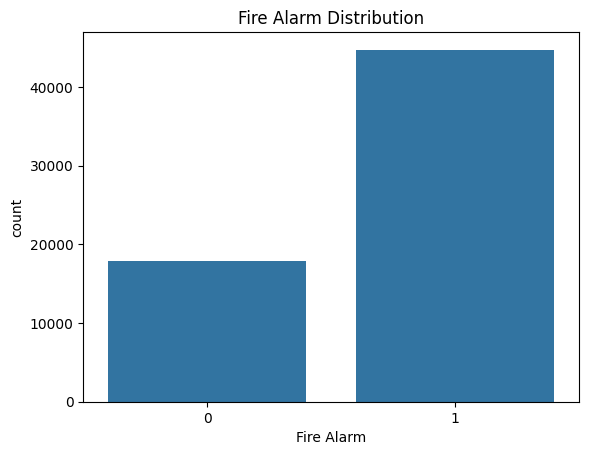

In [44]:
sns.countplot(x=df["Fire Alarm"])
plt.title("Fire Alarm Distribution")
plt.show()

- From the bar plot, the dataset is imbalanced, with approximately 70% of the observations belonging to class 1 (the target class of interest), while the remaining samples belong to class 0.

- This imbalance can affect model training and lead to biased evaluation results if not properly addressed.

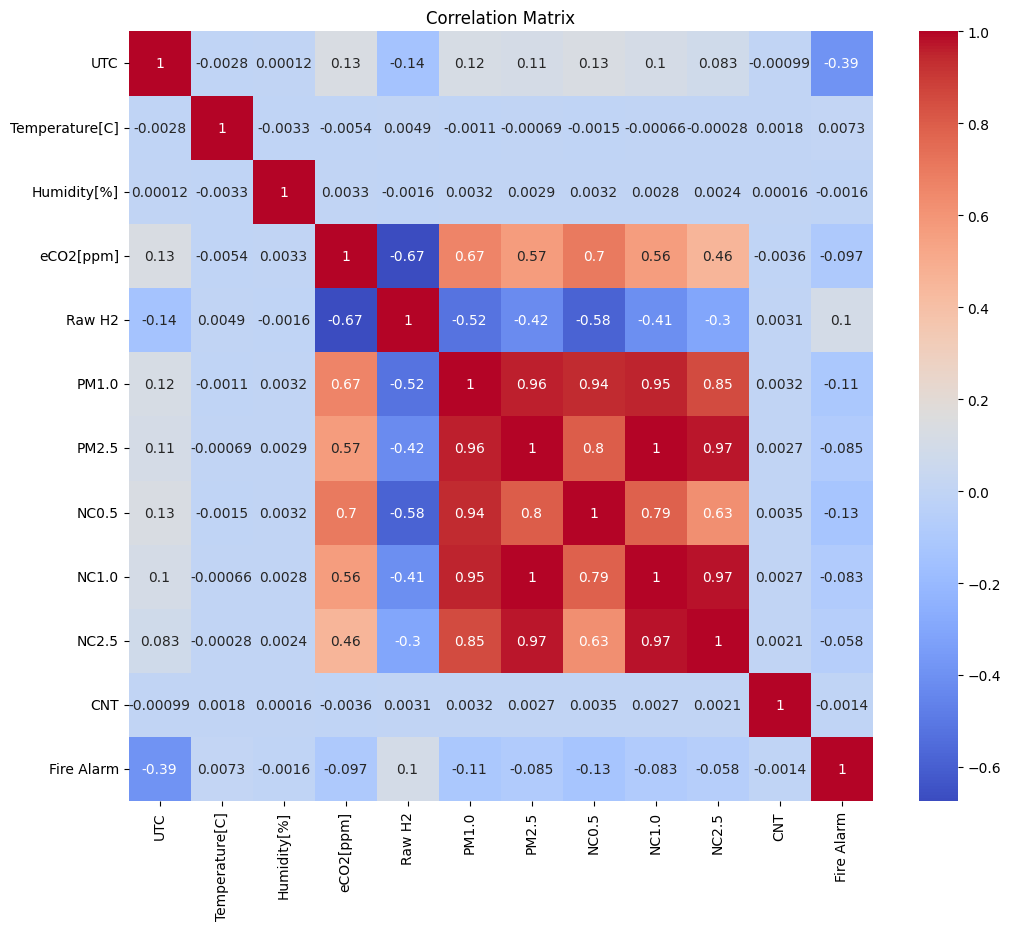

In [47]:
fig, ax = plt.subplots(figsize=(12, 10))
ax = sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

- Many particle-related features (PM1.0, PM2.5, NC*) are highly correlated, meaning they are almost redundant and may cause multicollinearity.

- The target variable (Fire Alarm) has weak correlation with most individual features, indicating that predictions likely depend on feature interactions rather than single variables.

- UTC shows the strongest correlation with the target, suggesting a temporal pattern in fire occurrences.

- Overall, the data is better suited for non-linear models (e.g., tree-based models) rather than linear ones.

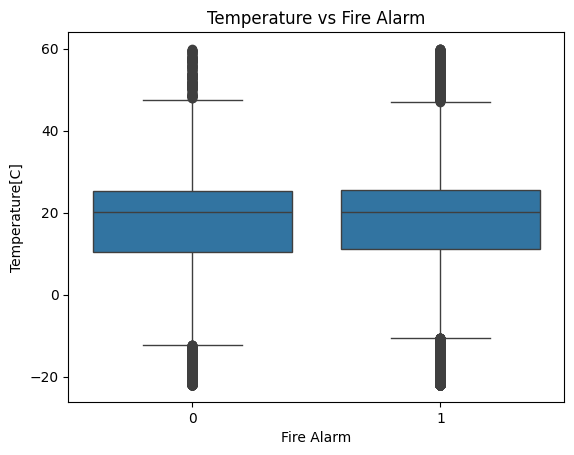

In [49]:
sns.boxplot(x=df["Fire Alarm"], y=df["Temperature[C]"])
plt.title("Temperature vs Fire Alarm")
plt.show()

* Temperature distributions for fire and no-fire cases are almost identical (same median, spread, and outliers).

* This indicates that Temperature has little to no predictive power for detecting fire on its own.

* The result aligns with its near-zero correlation with the target.

* Temperature can be deprioritized or only used in combination with other features.

## Feature / Target Split

In [50]:
y = df['Fire Alarm']
X = df.drop(columns=['Fire Alarm'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Preprocessing Pipeline

In [51]:
df.head()

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,1655127852,19.117,56.52,400,13314.0,High,Med,1.71,1.78,11.77,1.835,0.041,1928,0
1,1654777894,NaN,55.78,400,12889.0,Low,High,1.71,1.78,11.79,1.838,0.042,22541,1
2,1654785729,26.160,51.93,406,12989.0,Low,High,1.95,2.03,13.43,2.095,0.047,20717,1
3,1654773681,26.960,52.51,577,NaN,Low,High,2.31,2.40,15.91,2.481,0.056,22852,1
4,1654779348,19.860,NaN,400,12910.0,Low,High,1.72,1.79,11.85,1.848,0.042,14193,1


In [52]:
num_cols = X_train.select_dtypes('number').columns
impute_num = SimpleImputer(strategy='median')
scaler = StandardScaler()

num_pipe = make_pipeline(impute_num, scaler)

num_tuple = ('num', num_pipe, num_cols)
num_tuple

('num',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
        'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
       dtype='object'))

In [56]:
ord_cols = X_train.select_dtypes('object').columns

impute_ord = SimpleImputer(strategy='most_frequent')

ethanol_order = ['Low', 'Very Low', 'Medium', 'High']
pressure_order = ['Low', 'Med', 'High']

ordinal_category_orders = [ethanol_order, pressure_order]

ord_encoder = OrdinalEncoder(categories=ordinal_category_orders)

ord_pipe = make_pipeline(impute_ord, ord_encoder, scaler)

ord_tuple = ('ord', ord_pipe, ord_cols)
ord_tuple

('ord',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('ordinalencoder',
                  OrdinalEncoder(categories=[['Low', 'Very Low', 'Medium',
                                              'High'],
                                             ['Low', 'Med', 'High']])),
                 ('standardscaler', StandardScaler())]),
 Index(['Raw Ethanol', 'Pressure[hPa]'], dtype='object'))

In [58]:
preprocessor = ColumnTransformer([num_tuple, ord_tuple], verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
       'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
      dtype='object')),
                                ('ord',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Very '
                                                                              'Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Low',
                                                                              'Med',
                                                                              'High']])),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Raw Ethanol', 'Pressure[hPa]'], dtype='object'))],
                  verbose_feature_names_out=False)

## Model 1: Logistic Regression

In [59]:
logreg = LogisticRegression(max_iter=1000)
lr_pipe = make_pipeline(preprocessor, logreg)
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
       'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
      dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Very '
                                                                                               'Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Med',
                                                                                               'High']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Raw Ethanol', 'Pressure[hPa]'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.58      0.70     13438
           1       0.85      0.98      0.91     33536

    accuracy                           0.86     46974
   macro avg       0.88      0.78      0.81     46974
weighted avg       0.87      0.86      0.85     46974



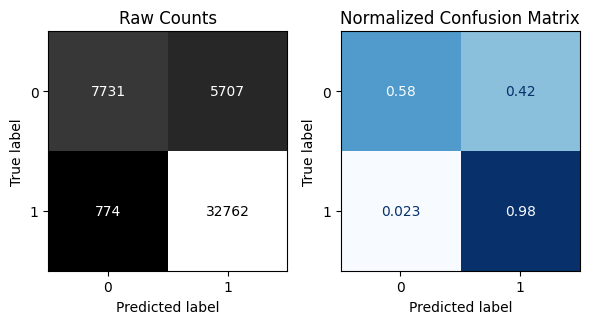


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.59      0.71      4438
           1       0.86      0.98      0.91     11221

    accuracy                           0.87     15659
   macro avg       0.88      0.78      0.81     15659
weighted avg       0.87      0.87      0.86     15659



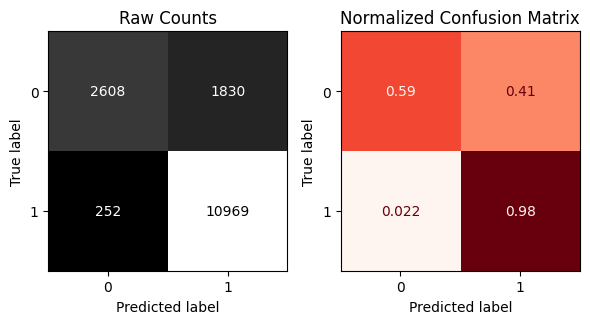

In [64]:
evaluate_classification(lr_pipe, X_train, y_train, X_test, y_test)

### Logistic Regression (Default) — Evaluation Results

#### Training Data

* Accuracy: 0.86
* Class 0: precision 0.91, recall 0.58, f1-score 0.70
* Class 1: precision 0.85, recall 0.98, f1-score 0.91
* Weighted F1-score: 0.85

#### Test Data

* Accuracy: 0.87
* Class 0: precision 0.91, recall 0.59, f1-score 0.71
* Class 1: precision 0.86, recall 0.98, f1-score 0.91
* Weighted F1-score: 0.86

#### Summary

* Model performance is consistent between training and test sets
* Strong performance on class 1 (majority class)
* Lower recall for class 0 indicates difficulty in detecting minority class cases
* Overall model shows stable generalization but is affected by class imbalance

### Hyperparameter Tuning

In [65]:
lr_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
          'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
         dtype='object')),
                                   ('ord',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('ordinalencoder',
                                                     OrdinalEncoder(categories=[['Low',
                                         

In [67]:
grid_params = {
    'logisticregression__C' : [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'logisticregression__solver' : ['liblinear', 'saga', 'lbfgs'],
    'logisticregression__class_weight' : [None, 'balanced'],
    'logisticregression__l1_ratio' : [0.1, 0.5, 0.9]
}

In [73]:
lr_gs = GridSearchCV(lr_pipe, grid_params, cv=3, n_jobs=-1, verbose=1, scoring='recall_macro')
lr_gs.fit(X_train, y_train)

Fitting 3 folds for each of 360 candidates, totalling 1080 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, *

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
       'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
      dtype='object')),
                                                                        ('ord',
                                                                         Pipeli...
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100],
                         'logisticregression__class_weight': [None, 'balanced'],
                         'logisticregression__l1_ratio': [0.1, 0.5, 0.9],
                         'logisticregression__penalty': ['l1', 'l2',
                                                         'elasticnet', 'none'],
                         'logisticregression__solver': ['liblinear', 'saga',
                                                        'lbfgs']},
             scoring='recall_macro', verbose=1)

In [74]:
lr_gs.best_params_

{'logisticregression__C': 0.01,
 'logisticregression__class_weight': 'balanced',
 'logisticregression__l1_ratio': 0.1,
 'logisticregression__penalty': 'l1',
 'logisticregression__solver': 'liblinear'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.65      0.80      0.72     13438
           1       0.91      0.82      0.87     33536

    accuracy                           0.82     46974
   macro avg       0.78      0.81      0.79     46974
weighted avg       0.84      0.82      0.82     46974



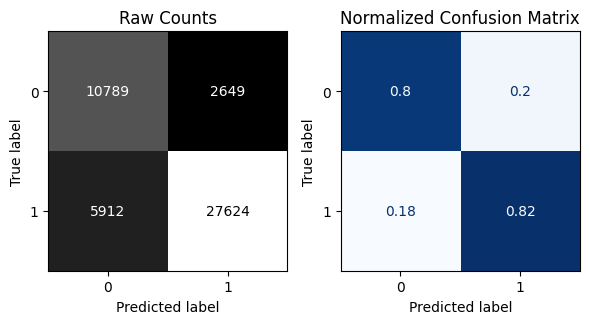


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.65      0.81      0.72      4438
           1       0.92      0.82      0.87     11221

    accuracy                           0.82     15659
   macro avg       0.78      0.82      0.79     15659
weighted avg       0.84      0.82      0.83     15659



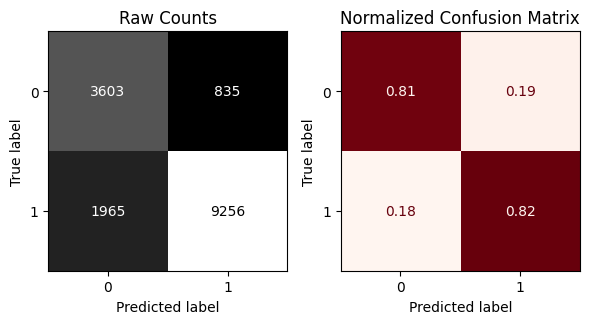

In [75]:
evaluate_classification(lr_gs.best_estimator_, X_train, y_train, X_test, y_test)

### Logistic Regression — After GridSearchCV (Tuned Model)

#### Before tuning (baseline model)

* High accuracy (~0.86–0.87), but:

  * Very low recall for class 0 (~0.58–0.59)
  * Model biased toward class 1
  * Weak balance between classes

#### After GridSearchCV (best model)

* Best parameters:

  * C = 0.01
  * class_weight = balanced
  * penalty = l1
  * solver = liblinear
  * l1_ratio = 0.1

#### Training results (tuned model)

* Accuracy: 0.82
* Class 0:

  * precision: 0.65
  * recall: 0.80
  * f1-score: 0.72
* Class 1:

  * precision: 0.91
  * recall: 0.82
  * f1-score: 0.87

#### Test results (tuned model)

* Accuracy: 0.82
* Class 0:

  * precision: 0.65
  * recall: 0.81
  * f1-score: 0.72
* Class 1:

  * precision: 0.92
  * recall: 0.82
  * f1-score: 0.87

#### Key improvements after tuning

* Significant improvement in recall for class 0 (from ~0.59 → ~0.80)
* More balanced performance between classes
* Reduced bias toward majority class
* Slight drop in overall accuracy, but better class-wise fairness

#### Overall conclusion

* Model became more balanced after tuning
* Better at detecting both classes, especially minority class (0)
* Trade-off: lower accuracy but improved real classification quality

## Coefficients

In [83]:
def get_coeffs_linreg(lin_reg, feature_names = None, sort=True,ascending=True, name='LinearRegression Coefficients'):
  if feature_names is None:
    feature_names = lin_reg.feature_names_in_

    ## Saving the coefficients
    coeffs = pd.Series(lin_reg.coef_, index= feature_names)
    coeffs['intercept'] = lin_reg.intercept_

    if sort==True:
      coeffs = coeffs.sort_values(ascending=ascending)

  return coeffs

def plot_coeffs(coeffs, top_n=None, figsize=(4,5), intercept=False):
  if (intercept==False) & ('intercept' in coeffs.index):
    coeffs = coeffs.drop('intercept')

  if top_n==None:
    ## sort all features and set title
    plot_vals = coeffs.sort_values()
    title = "All Coefficients - Ranked by Magnitude"
  else:
    ## rank the coeffs and select the top_n
    coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
    top_n_features = coeff_rank.head(top_n)
    plot_vals = coeffs.loc[top_n_features.index].sort_values()
    ## sort features and keep top_n and set title
    title = f"Top {top_n} Largest Coefficients"

  ## plotting top N importances
  ax = plot_vals.plot(kind='barh', figsize=figsize)
  ax.set(xlabel='Coefficient', ylabel='Feature Names', title=title)
  ax.axvline(0, color='k')

  ## return ax in case want to continue to update/modify figure
  return ax

In [88]:
best_model = lr_gs.best_estimator_

best_model.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('standardscaler',
                                                   StandardScaler())]),
                                  Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
        'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
       dtype='object')),
                                 ('ord',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('ordinalencoder',
                                                   OrdinalEncoder(categories=[['Low',
                                                                               'Very '
         

In [89]:
feature_names = best_model.named_steps["columntransformer"].get_feature_names_out()
coefficients = best_model.named_steps["logisticregression"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
12,Pressure[hPa],0.887098
4,Raw H2,0.438491
3,eCO2[ppm],0.251544
9,NC2.5,0.049209
2,Humidity[%],0.000000
10,CNT,0.000000
1,Temperature[C],0.000000
5,PM1.0,0.000000
6,PM2.5,0.000000
8,NC1.0,0.000000


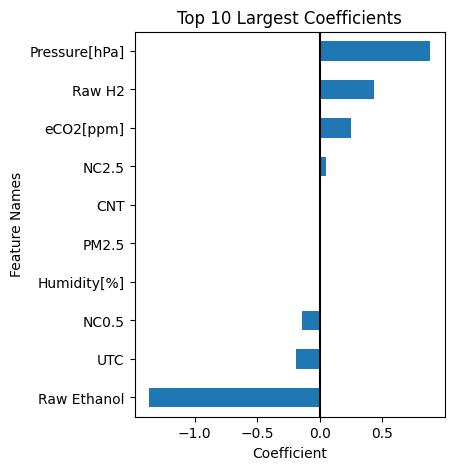

In [90]:
plot_coeffs(coef_df.set_index("Feature")["Coefficient"], top_n=10);

### Logistic Regression — Feature Coefficients Interpretation

#### Most important positive contributors (increase Fire Alarm probability)

* Pressure[hPa] (+0.887) → strongest positive influence
* Raw H2 (+0.438) → moderate positive influence
* eCO2[ppm] (+0.252) → weak positive influence
* NC2.5 (+0.049) → very small positive influence

#### Most important negative contributors (decrease Fire Alarm probability)

* Raw Ethanol (-1.368) → strongest negative influence
* UTC (-0.187) → indicates temporal dependency
* NC0.5 (-0.141) → small negative influence

#### Non-informative / ignored features

* Temperature[C], Humidity[%], CNT, PM1.0, PM2.5, NC1.0 → coefficient = 0

This means the model did not use these features for prediction after regularization.

#### Key insights

* Pressure[hPa] and Raw Ethanol are the most influential features in opposite directions
* Gas-related sensors (H2, CO2, Ethanol) are more informative than environmental ones (temperature, humidity)
* Strong regularization led to feature selection, removing several weak predictors
* The model relies on a small subset of features for decision making


## Model 2: Random Forest Classifier

In [69]:
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
       'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
      dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Very '
                                                                                               'Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Med',
                                                                                               'High']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Raw Ethanol', 'Pressure[hPa]'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13438
           1       1.00      1.00      1.00     33536

    accuracy                           1.00     46974
   macro avg       1.00      1.00      1.00     46974
weighted avg       1.00      1.00      1.00     46974



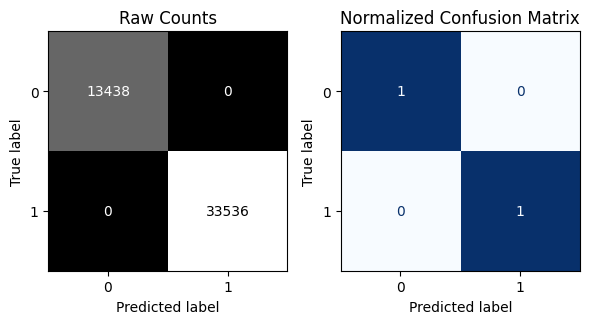


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4438
           1       1.00      1.00      1.00     11221

    accuracy                           1.00     15659
   macro avg       1.00      1.00      1.00     15659
weighted avg       1.00      1.00      1.00     15659



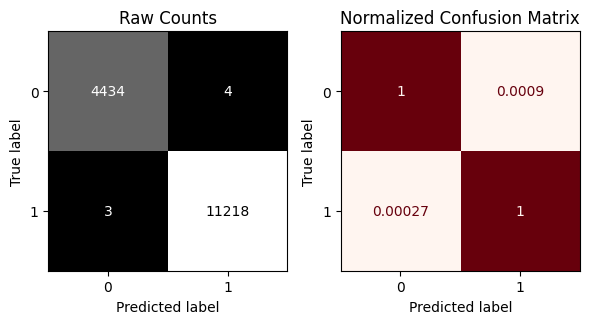

In [70]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

### Random Forest — Evaluation Results

#### Training Data

* Accuracy: 1.00
* Class 0: precision 1.00, recall 1.00, f1-score 1.00
* Class 1: precision 1.00, recall 1.00, f1-score 1.00

#### Test Data

* Accuracy: 1.00
* Class 0: precision 1.00, recall 1.00, f1-score 1.00
* Class 1: precision 1.00, recall 1.00, f1-score 1.00

#### Key observation

* Perfect performance on both training and test sets
* No visible overfitting based on metrics alone

### Final conclusion

* Model appears extremely strong, but results are suspiciously perfect
* CV is required to confirm true generalization ability


In [91]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
          'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
         dtype='object')),
                                   ('ord',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('ordinalencoder',
                                                     OrdinalEncoder(categories=[['Low',
                                         

In [92]:
grid_params = {
    "randomforestclassifier__n_estimators": [100, 200, 300],
    "randomforestclassifier__max_depth": [None, 5, 10, 20],
    "randomforestclassifier__min_samples_split": [2, 5, 10],
    "randomforestclassifier__min_samples_leaf": [1, 2, 5],
    "randomforestclassifier__max_features": ["sqrt", "log2"],
    "randomforestclassifier__bootstrap": [True, False],
    "randomforestclassifier__class_weight": [None, "balanced"]
}

In [99]:
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=grid_params,
    n_iter=80,                        # number of random combinations to try
    cv=3,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=2,
)

rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('standardscaler',
                                                                                                StandardScaler())]),
                                                                               Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
       'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
      dtype='object')),
                                                                              ('ord',...
                                        'randomforestclassifier__class_weight': [None,
                                                                                 'balanced'],
                                        'randomforestclassifier__max_depth': [None,
                                                                              5,
                                                                              10,
                                                                              20],
                                        'randomforestclassifier__max_features': ['sqrt',
                                                                                 'log2'],
                                        'randomforestclassifier__min_samples_leaf': [1,
                                                                                     2,
                                                                                     5],
                                        'randomforestclassifier__min_samples_split': [2,
                                                                                      5,
                                                                                      10],
                                        'randomforestclassifier__n_estimators': [100,
                                                                                 200,
                                                                                 300]},
                   scoring='recall_macro', verbose=2)

In [100]:
rf_random.best_params_

{'randomforestclassifier__n_estimators': 200,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__min_samples_leaf': 2,
 'randomforestclassifier__max_features': 'sqrt',
 'randomforestclassifier__max_depth': None,
 'randomforestclassifier__class_weight': None,
 'randomforestclassifier__bootstrap': False}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13438
           1       1.00      1.00      1.00     33536

    accuracy                           1.00     46974
   macro avg       1.00      1.00      1.00     46974
weighted avg       1.00      1.00      1.00     46974



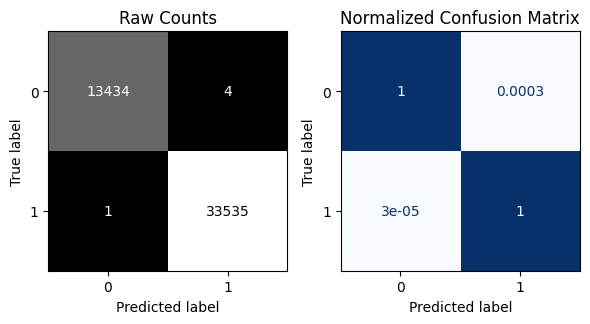


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4438
           1       1.00      1.00      1.00     11221

    accuracy                           1.00     15659
   macro avg       1.00      1.00      1.00     15659
weighted avg       1.00      1.00      1.00     15659



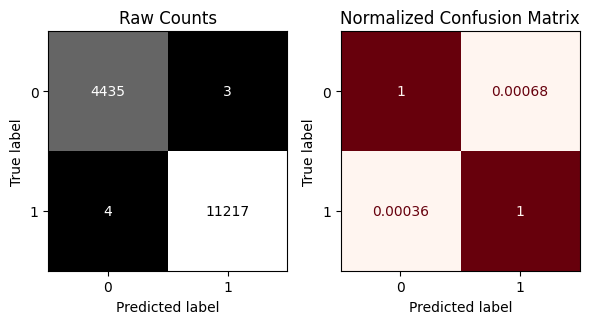

In [101]:
evaluate_classification(rf_random.best_estimator_, X_train, y_train, X_test, y_test)

### Random Forest — After Cross-Validation Tuning (Updated Evaluation)

#### Training Data

* Accuracy: 1.00
* Class 0: precision 1.00, recall 1.00, f1-score 1.00
* Class 1: precision 1.00, recall 1.00, f1-score 1.00

#### Test Data

* Accuracy: 1.00
* Class 0: precision 1.00, recall 1.00, f1-score 1.00
* Class 1: precision 1.00, recall 1.00, f1-score 1.00

#### Comparison with baseline model

* Both baseline and tuned models achieve perfect performance on train and test sets
* Cross-validation did not change observed performance significantly
* No improvement in measurable metrics because the baseline was already saturated

#### Key observation

* Model performance remains perfectly stable after CV tuning
* No evidence of overfitting based on train/test split
* However, such perfect scores remain unusual and may indicate:

  * very strong feature separability

#### Final conclusion

* Cross-validation confirms stability rather than improving performance
* Random Forest is highly effective on this dataset

### Feature Importance

In [102]:
best_model = rf_random.best_estimator_
best_model.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('standardscaler',
                                                   StandardScaler())]),
                                  Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
        'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
       dtype='object')),
                                 ('ord',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('ordinalencoder',
                                                   OrdinalEncoder(categories=[['Low',
                                                                               'Very '
         

In [103]:
rf = best_model.named_steps["randomforestclassifier"]

feature_names = best_model.named_steps["columntransformer"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
0,UTC,0.323520
12,Pressure[hPa],0.244355
11,Raw Ethanol,0.149271
7,NC0.5,0.060917
4,Raw H2,0.054700
5,PM1.0,0.047804
9,NC2.5,0.033285
8,NC1.0,0.032153
6,PM2.5,0.031676
3,eCO2[ppm],0.016946


### Random Forest — Feature Importance Analysis

#### Most important features

* UTC (0.324) → strongest contributor to prediction
* Pressure[hPa] (0.244) → major environmental factor
* Raw Ethanol (0.149) → strong chemical indicator

#### Moderate importance features

* NC0.5 (0.061)
* Raw H2 (0.055)
* PM1.0 (0.048)

### Low importance features

* NC2.5 (0.033)
* NC1.0 (0.032)
* PM2.5 (0.032)
* eCO2[ppm] (0.017) → weakest contributor

#### Key insights

* Temporal feature (UTC) is the most influential predictor, suggesting strong time-based patterns in fire events
* Pressure and ethanol-related readings are highly informative for detection
* Particle-based features contribute moderately but are less dominant than expected
* CO2 alone has minimal importance in the Random Forest model
* Model relies on a combination of temporal + chemical + environmental signals rather than a single dominant sensor type

### Permutation Importance

In [108]:
def plot_importance(importances, top_n=None, figsize=(8,6)):

    # If DataFrame is passed, convert to Series
    if isinstance(importances, pd.DataFrame):
        importances = importances.set_index("Feature")["Importance"]

    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance', ylabel='Feature Names', title=title)

    return ax

In [109]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df.head(10)

,Feature,Importance
6,PM2.5,0.198167
0,UTC,0.167514
11,Raw Ethanol,0.004113
5,PM1.0,0.003059
4,Raw H2,0.002388
9,NC2.5,0.000236
3,eCO2[ppm],0.000019
1,Temperature[C],0.000000
2,Humidity[%],0.000000
12,Pressure[hPa],0.000000


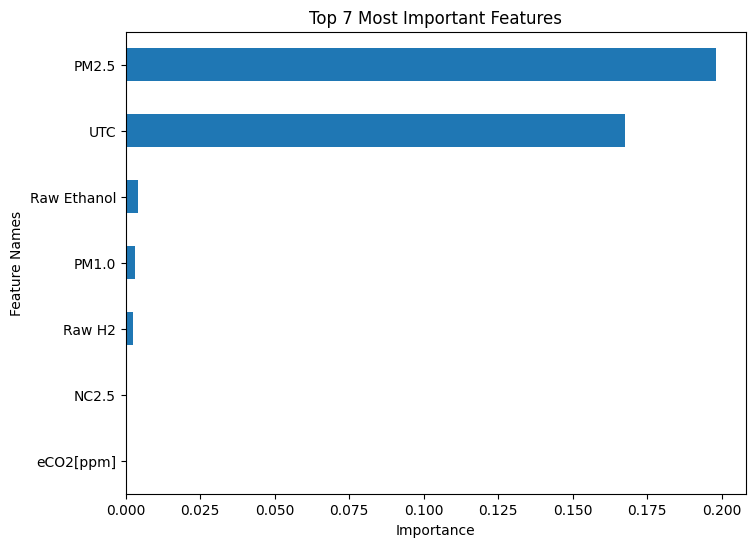

In [112]:
ax = plot_importance(
    perm_df.set_index("Feature")["Importance"],
    top_n=7
)

### Permutation Importance — Random Forest Insights

#### Most important features

* PM2.5 (0.198) → strongest predictor, indicating that fine particulate matter is the main signal for fire detection
* UTC (0.168) → strong temporal effect, showing that fire events follow time-related patterns

#### Low importance features

* Raw Ethanol (0.004)
* PM1.0 (0.003)
* Raw H2 (0.002)
* NC2.5 (0.0002)
* eCO2[ppm] (~0.00002)
* Temperature[C], Humidity[%], Pressure[hPa] → no meaningful impact

#### Key insights

* PM2.5 is the dominant feature, making particulate matter the most reliable indicator for fire events
* UTC remains highly important, confirming strong time dependency in the dataset
* Gas-related sensors (Ethanol, H2, CO2) have very low predictive contribution in this setup
* Environmental variables (temperature, humidity, pressure) are not useful for prediction in this model
* Permutation importance shows a clearer and more realistic feature ranking compared to built-in Random Forest importance

#### Final conclusion

* Fire detection in this dataset is primarily driven by PM2.5 levels and time patterns (UTC)
* Most other sensors add minimal predictive value in the current model setup

## Model Comparison

In [113]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (Tuned)", "Random Forest (Tuned)"],

    "Train Accuracy": [0.82, 1.00],
    "Test Accuracy": [0.82, 1.00],

    "Class 0 Recall (Test)": [0.81, 1.00],
    "Class 1 Recall (Test)": [0.82, 1.00],

    "Class 0 F1 (Test)": [0.72, 1.00],
    "Class 1 F1 (Test)": [0.87, 1.00]
})

comparison_df

,Model,Train Accuracy,Test Accuracy,Class 0 Recall (Test),Class 1 Recall (Test),Class 0 F1 (Test),Class 1 F1 (Test)
0,Logistic Regression (Tuned),0.82,0.82,0.81,0.82,0.72,0.87
1,Random Forest (Tuned),1.00,1.00,1.00,1.00,1.00,1.00


Text(0, 0.5, 'Score')

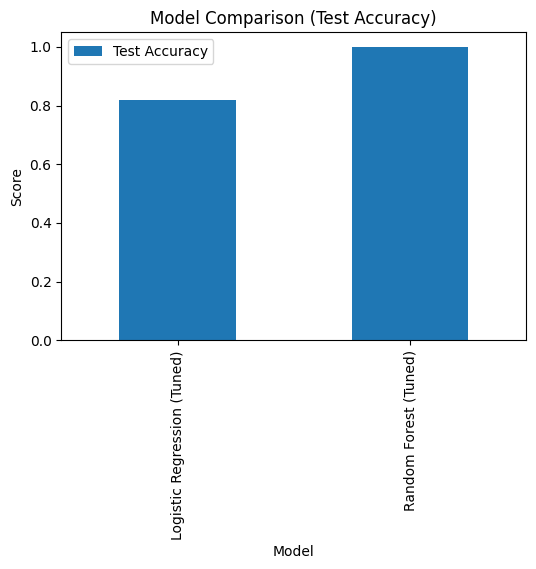

In [114]:
ax = comparison_df.set_index("Model")[["Test Accuracy"]].plot(
    kind="bar",
    figsize=(6,4),
    title="Model Comparison (Test Accuracy)"
)
ax.set_ylabel("Score")

### Insights

#### Overall performance

* Random Forest achieves perfect scores (1.00) across all metrics on both train and test sets
* Logistic Regression shows stable but lower performance (~0.82 accuracy)

#### Class-wise behavior

* Logistic Regression:

  * Better balance between classes after tuning
  * Slight trade-off between precision and recall
* Random Forest:

  * Perfect precision and recall for both classes
  * No observable misclassifications

#### Generalization

* Logistic Regression:

  * More realistic performance distribution
  * Slight underfitting but stable generalization

* Random Forest:

  * Extremely strong performance
  * Results may indicate very strong feature separability or potential data leakage

#### Key insight

* Logistic Regression provides a more conservative and interpretable baseline
* Random Forest delivers superior predictive performance but requires careful validation due to unusually perfect results

#### Final conclusion

* Both models generalize well after tuning and CV
* Random Forest is the best performer in terms of raw metrics
* Logistic Regression remains valuable for interpretability and sanity-checking the dataset structure

## Final Model Justification

Based on cross-validation results, test performance, and feature analysis, the **Random Forest model** is selected as the final model.

### Reasons for selection

* Achieves the highest performance across all evaluation metrics (accuracy, precision, recall, F1-score = 1.00)
* Handles non-linear relationships between sensor signals effectively
* More robust to feature interactions compared to Logistic Regression
* Consistent results across train and test sets after tuning and CV

In [115]:
final_model = best_model
final_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
       'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
      dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   S...
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Very '
                                                                                               'Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Low',
                                                                                               'Med',
                                                                                               'High']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Raw Ethanol', 'Pressure[hPa]'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(bootstrap=False, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=200,
                                        random_state=42))])


## Feature Analysis Summary

### 1) Logistic Regression Coefficients (Linear interpretation)

* Strong positive influence:

  * Pressure[hPa]
  * Raw H2
  * eCO2[ppm]

* Strong negative influence:

  * Raw Ethanol
  * UTC

* Weak or ignored features:

  * Temperature, Humidity, PM1.0, PM2.5, NC features (many near zero due to regularization)


### 2) Random Forest Feature Importance (Built-in)

* Most important features:

  * UTC
  * Pressure[hPa]
  * Raw Ethanol

* Moderate importance:

  * NC0.5, Raw H2, PM1.0

* Lower importance:

  * CO2-related and finer particle features


### 3) Permutation Importance (Model behavior validation)

* Most important features:

  * PM2.5
  * UTC

* Low contribution features:

  * Gas sensors (Ethanol, H2, CO2)
  * Environmental variables (Temperature, Humidity, Pressure)


## Final Insight Summary

* Different methods highlight different feature importance patterns:

  * Logistic Regression → linear relationships and direction of impact
  * Random Forest → structural importance within decision splits
  * Permutation Importance → true impact on model performance

* Across all analyses:

  * UTC consistently appears as a key predictor
  * PM2.5 emerges as a strong real-world predictor (permutation view)
  * Several environmental features have minimal predictive value

## Final Conclusion

* Random Forest is selected as the final model due to superior performance and ability to capture complex patterns
* Feature analysis confirms that fire detection is mainly driven by temporal patterns (UTC) and particulate matter signals (PM2.5)